In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [38]:
# Load the dataset
data = fetch_california_housing(as_frame=True)

# Combine features and the target variable ('HousePrice') into a single dataframe
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Display the first 5 rows to review the data
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [39]:
# X will contain all columns except 'HousePrice'
X = df.drop("HousePrice", axis=1)

# y will only contain 'HousePrice', which is what we want to predict
y = df["HousePrice"]

print("Features (X) and Target (y) separated.")

Features (X) and Target (y) separated.


In [40]:
scaler = StandardScaler()

# Scale the feature data
X_scaled = scaler.fit_transform(X)

print("Feature scaling done!")

Feature scaling done!


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (16512, 8)
Testing data size: (4128, 8)


In [42]:
# Define the three models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

results = {}

# Loop through the models to train and test each one
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    predictions = model.predict(X_test)
    
    # Evaluate performance (Updated RMSE code)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Save the results
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert the results into a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("Model Comparison Table:")
display(results_df)

Model Comparison Table:


,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


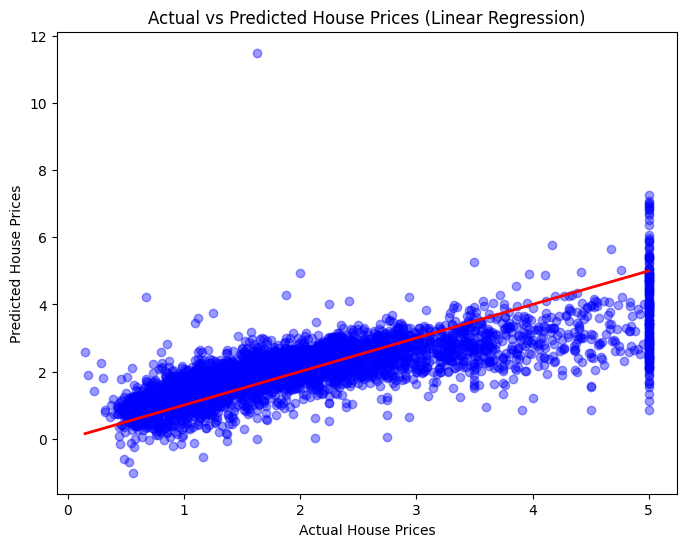

In [43]:
# Re-train the chosen model to generate predictions for plotting (using Linear Regression as an example)
best_model = LinearRegression()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Plot the graph
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Linear Regression)")

# Draw a perfect prediction reference line (Red line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)

plt.show()